# **importing KAGGLE.json file**

In [ ]:
import os
from google.colab import files
files.upload() # This will prompt you to select your kaggle.json file

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vysakhm009","key":"ed74c040df017eb15c6c85e92b835f3e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# **Epic 1: Data Collection & Data Preprocessing**

## **Activity 1.1: Download the Dataset**

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 98% 2.65G/2.70G [00:17<00:00, 288MB/s]
100% 2.70G/2.70G [00:17<00:00, 166MB/s]


In [ ]:
!unzip -q new-plant-diseases-dataset.zip

In [ ]:
import os

# Define the path to the specific training folder
apple_scab_path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab'

# Count the files
num_images = len(os.listdir(apple_scab_path))
print(f"Number of training images for Apple Scab: {num_images}")

Number of training images for Apple Scab: 2016


## **Activity 1.2: Data Exploration and Visualization**

## **Activity 1.2.1: Configure Dataset Paths**

In [ ]:
from logging import BASIC_FORMAT
IMG_SIZE = (224, 224)
EPOCHS = 10
BATCH_SIZE = 32
N_LAST_LAYERS = 10
SEED = 1337

train_dir = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

for p in [train_dir, valid_dir]:
  if not os.path.exists(p):
    print(f"ERROR: {p} does not exist")
    sys.exit(1)

print("train_dir:", train_dir)
print("valid_dir:", valid_dir)

train_dir: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
valid_dir: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


## **Activity 1.2.2: Visualize Sample Images**

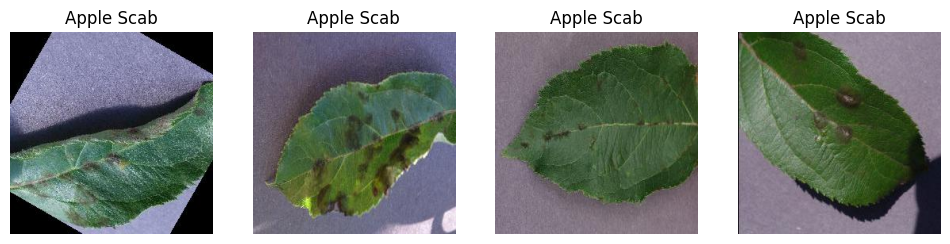

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Get a list of image filenames
folder_path = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab'
images = os.listdir(folder_path)

# Pick 4 random images to display
plt.figure(figsize=(12, 12))
for i in range(4):
    random_img = random.choice(images)
    img_path = os.path.join(folder_path, random_img)

    img = mpimg.imread(img_path)
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title("Apple Scab")
    plt.axis('off')

plt.show()

In [ ]:
import random
from IPython.display import Image, display
# Function to display random samples frcyn each class
def show_sample_image(base_path,num_classes=5, images_per_class=3):
  """Display random sample images from the dataset"""
  class_names = os.listdir(base_path)
  random_classes = random.sample(class_names,min(num_classes,len(class_names)))

  fig, axes = plt.subplots(num_classes, images_per_class,
                           figsize=(12,3*num_classes))
  fig.suptitle("Sample images from the dataset",fontsize=16)

  for i, class_name in enumerate(random_classes):
    class_path = os.path.join(base_path, class_name)
    images = os.listdir(class_path)
    random_images = random.sample(images, min(images_per_class,len(images)))

    for j, img_name in enumerate(random_images):
      img_path = os.path.join(class_path, img_name)
      axes[i,j].imshow(img)
      axes[i,j].axis('off')
      if j==0:
        axes[i,j].set_title(class_name.replace('___','\n'),fontsize = 10)
  plt.tight_layout()
  plt.show()



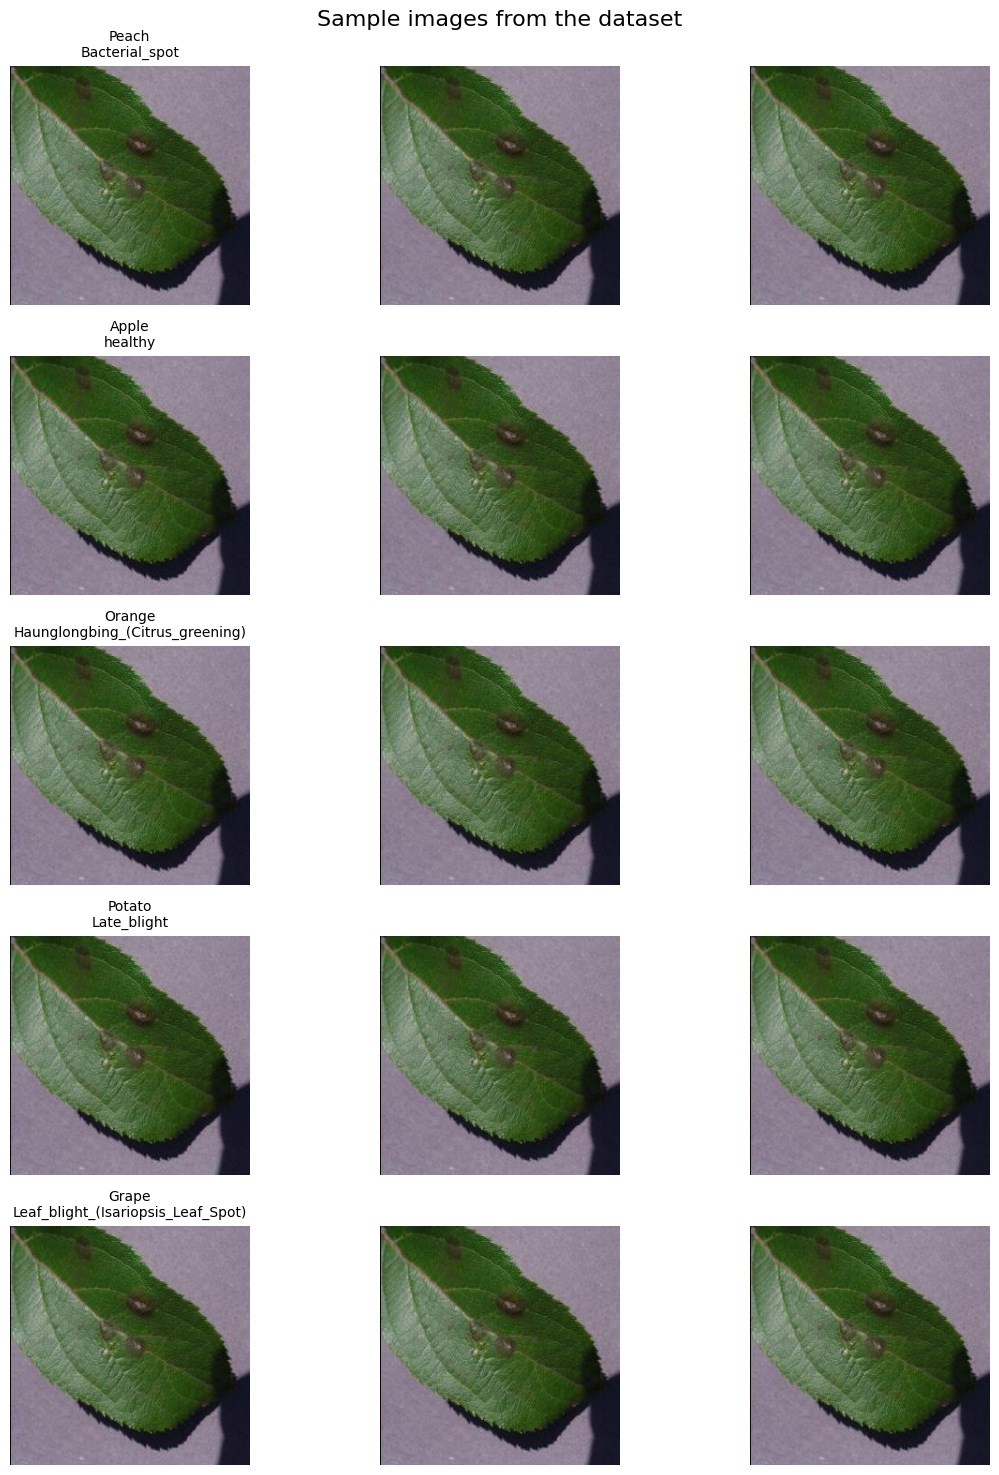

In [ ]:
show_sample_image(train_dir, num_classes=5, images_per_class=3)

## **Activity 1.2.3: Dataset Statistics**

In [ ]:
def count_images(directory):
  """Count the number of images in each class"""
  total_images = 0
  class_counts = {}
  for class_name in os.listdir(directory):
    class_path = os.path.join(directory, class_name)
    if os.path.isdir(class_path):
      num_images = len(os.listdir(class_path))
      class_counts[class_name] = num_images
      total_images += num_images
  return total_images, class_counts

train_total,train_counts = count_images(train_dir)
valid_total,valid_counts = count_images(valid_dir)

print(f"Training imges: {train_total}")
print(f"Validation images: {valid_total}")
print(f"Number of classes: {len(train_counts)}")
print(f"\nClass Distribution (first 10): ")
for i, (class_name, count) in enumerate(list(train_counts.items())[:10]):
  print(f"{class_name}: {count} Images")

Training imges: 70295
Validation images: 17572
Number of classes: 38

Class Distribution (first 10): 
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 Images
Apple___Apple_scab: 2016 Images
Pepper,_bell___Bacterial_spot: 1913 Images
Peach___healthy: 1728 Images
Tomato___healthy: 1926 Images
Squash___Powdery_mildew: 1736 Images
Tomato___Tomato_mosaic_virus: 1790 Images
Peach___Bacterial_spot: 1838 Images
Pepper,_bell___healthy: 1988 Images
Tomato___Early_blight: 1920 Images


## **Activity 1.3: Data Preprocessing and Augmentation**

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
preprocessing_function=preprocess_input,
horizontal_flip=True,
rotation_range=20,
zoom_range=0.15,
width_shift_range=0.1,
height_shift_range=0.1,
fill_mode='reflect'
)

valdi_datagen = ImageDataGenerator(
preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
train_dir,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode = 'categorical',
shuffle=True,
seed=SEED
)

valid_gen  = valdi_datagen.flow_from_directory(
valid_dir,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode = 'categorical',
shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


# **Epic 2: Model Building**

## **Activity 2.1 : Understanding Transfer Learning with MobileNetV2**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
  layer.trainable = False

if N_LAST_LAYERS > 0:
  for layer in base_model.layers[-N_LAST_LAYERS:]:
    layer.trainable = True

trainable_count = sum([tf.size(w).numpy() for w in base_model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in base_model.non_trainable_weights])

print(f"Trainable weights: {trainable_count:,}")
print(f"Non-trainable weights: {non_trainable_count:,}")
print(f"Unfrozen Last {N_LAST_LAYERS} Layers for fine-tuning")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weights: 732,480
Non-trainable weights: 1,525,504
Unfrozen Last 10 Layers for fine-tuning


In [ ]:
NUM_CLASSES = len(train_counts)

inputs= keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.35)(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs,outputs, name ="mobilenetv2_plant_disease_classifire")

model.summary()

Model: "mobilenetv2_plant_disease_classifire"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 1,070,182 (4.08 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

# **EPIC 3: MODEL TRAINING**

## **Activity 3.1 : Compile the Model**

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model compiled successfully!")
print(f"Optimizer: Adam(lr = 1e-4)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam(lr = 1e-4)
Loss function: Categorical Crossentropy
Metrics: Accuracy


## **Activity 3.2: Setup Training Callbacks**

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "/content/mobilenetv2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
]

print("Callbacks configured: ")
print("  1. ModelCheckpoint")
print("  2. ReduceLROnPlateau")
print("  3. EarlyStopping")

Callbacks configured: 
  1. ModelCheckpoint
  2. ReduceLROnPlateau
  3. EarlyStopping


## **Activity 3.3: Train the Model**

In [ ]:
history = model.fit(
    train_gen,
    steps_per_epoch=100,  # Limits training to 100 batches per epoch for speed
    epochs=EPOCHS,
    validation_data=valid_gen,
    validation_steps=50,   # Limits validation to 50 batches for speed
    callbacks=callbacks
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.1396 - loss: 3.3730
Epoch 1: val_accuracy improved from None to 0.12188, saving model to /content/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/mobilenetv2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.2875 - loss: 2.8337 - val_accuracy: 0.1219 - val_loss: 2.8954 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.6586 - loss: 1.5021
Epoch 2: val_accuracy improved from 0.12188 to 0.41438, saving model to /content/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/mobilenetv2_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7086 - loss: 1.2601 - val_accuracy: 0.4144 - val_loss: 1.8925 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.7810 - loss: 0.8549
Epoch 3: val_accuracy improved from 0.41438 to 0.52500, saving model to /content/mobilenetv2_best.keras



## **Activity 3.4: Visualize Training History**

Text(0.5, 1.0, 'Training and Validation Loss')

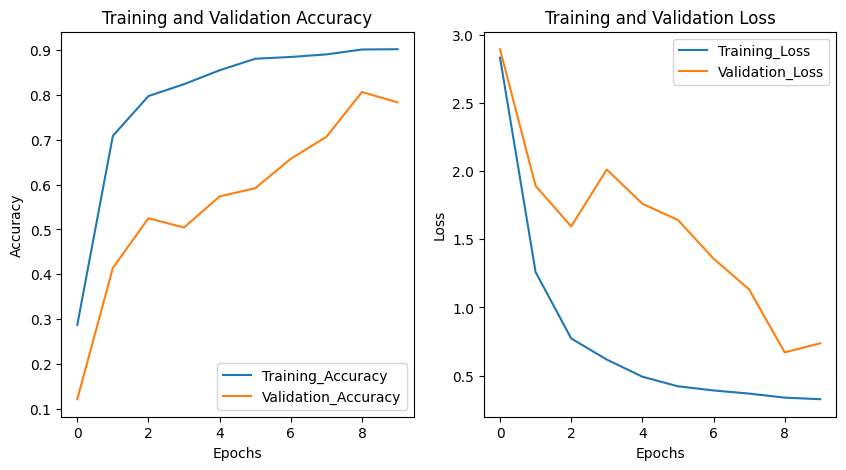

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy',[]),label='Training_Accuracy')
plt.plot(history.history.get('val_accuracy',[]),label='Validation_Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history.get('loss',[]),label='Training_Loss')
plt.plot(history.history.get('val_loss',[]),label='Validation_Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# **Epic 4: Model Evaluation and Testing**

## **Activity 4.1 : Evaluate Model Performance**

In [ ]:
# Evaluate the model on the validation set
print("Evaluating model performance...")
val_loss, val_accuracy = model.evaluate(valid_gen)

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Save the final model
model_save_path = 'plant_disease_model_final.h5'
model.save(model_save_path)
print(f"\nFinal model saved to: {model_save_path}")

Evaluating model performance...
550/550 ━━━━━━━━━━━━━━━━━━━━ 359s 653ms/step - accuracy: 0.8206 - loss: 0.6550



Validation Loss: 0.6550
Validation Accuracy: 0.8206

Final model saved to: plant_disease_model_final.h5


550/550 ━━━━━━━━━━━━━━━━━━━━ 350s 636ms/step


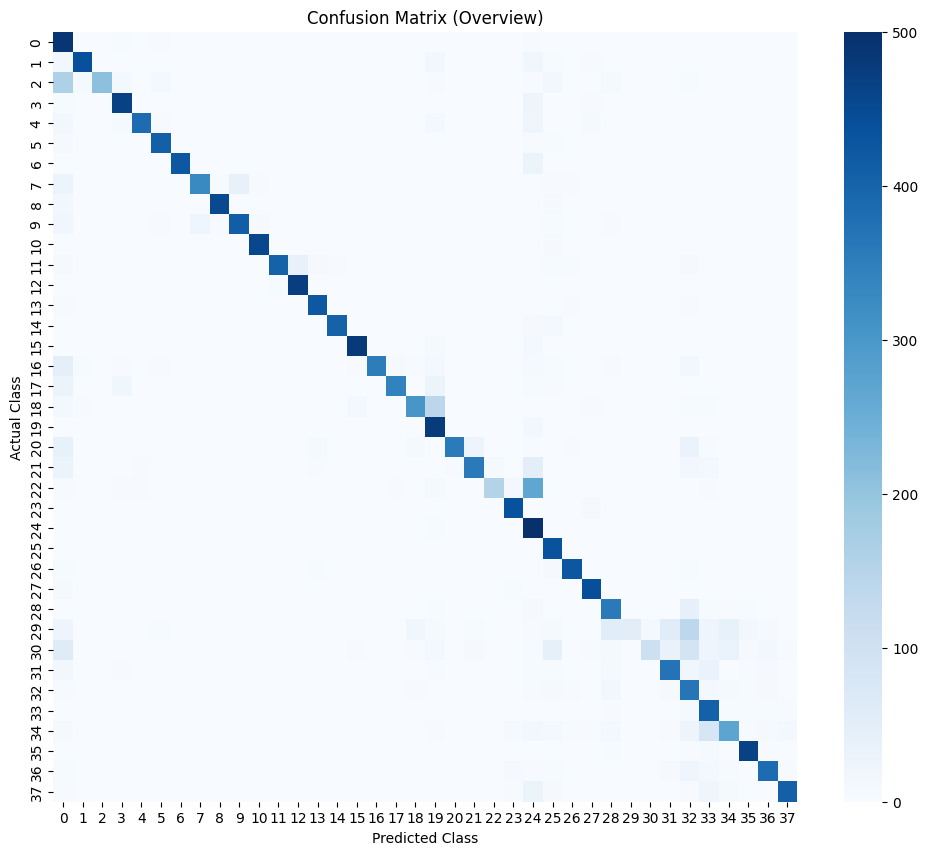

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get predictions for the validation set
y_pred = np.argmax(model.predict(valid_gen), axis=1)
y_true = valid_gen.classes

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot a simplified heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Overview)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

## **Activity 4.2 : Save the Final Model**